In [39]:
### importing the required libraries
using CSV
using DataFrames
using Statistics
using Plots
using DataStructures  # For the Counter function

In [40]:
module Read
    include("Read_data_files.jl")
end

module Check
    include("Check_files_exist.jl")
end

Main.Check

In [41]:
### change this to the job id for the experiment you want to analyze
## or the name you want to give the folder where all the extracted data files will be stored
JOB_ID = 67114439
### make sure to write dispersal parameters as floats to keep file name consistent ###

## vary these for different dispersal scenarios
gamma = 2.0    # dispersal rate from release site to household
rho = 0.33      # rate visit the households
tau = 0.33      # rate leave the households
alpha = 0.1     # dispersal rate of females moving from household directly to another household

num_simulations = 100  # number of realisations of SSA to run, 10,000 is a good number for the paper
rel_type = "relcom"

"relcom"

In [42]:
# Define parameters dictionary
fem_w0 = 0  # how many wildtypes and infected mosquitoes starting off with
male_w0 = 0
fem_m0 = 8
male_m0 = 8
m_free0 = 0 # no. of free wild-type
w_free0 = 0 # no. of free Wolbachia

# model parameters
phi = 0.85      # wolbachia fitness effect on birth rate
K = 30          # carrying capacity of mosquitoes per household
d = 12/100      # death rate of mosquitoes
k = 0.3         # larval density parameter
h = 0.19*100^k  # larval density parameter
b = 0.54        # per capita birth rate of mosquitoes (wildtypes)
H = 100         # number of households
u = 1           # vertical transmission probability
v = 1           # CI effect, proportion of non-viable offspring from infected male and wildtype female birth

rel_t = 150   # initial release time
delta_rel = 0 # time in days between releases, currently set to a single release inside the SSA code
## remember this is per household for the household releases so should use smaller release numbers
## currently set for community wide release
rel_size = 8*H # total number of Wolbachia-infected mosquitoes released into the community

t_start = 0    
t_end = 1000   # start time and end time (days) of simulation

result_length = length(t_start:t_end) # number of time points to store results
weeks = round(Int,result_length/7)    # number of weeks to store results

parameters = Dict(           # dictionary of parameters
    :fem_m0 => fem_m0,
    :male_m0 => male_m0,
    :fem_w0 => fem_w0,
    :male_w0 => male_w0,
    :m_free0 => m_free0,
    :w_free0 => w_free0,
    :rho => rho,
    :phi => phi,
    :b => b,
    :K => K,
    :d => d,
    :h => h,
    :k => k,
    :u => u,
    :v => v,
    :tau => tau,
    :H => H,
    :t_start => t_start,
    :t_end => t_end,
    :seed => 1234,
    :delta_rel => delta_rel,
    :rel_size => rel_size,
    :gamma => gamma,
    :alpha => alpha,
    :rel_t => rel_t
)

Dict{Symbol, Real} with 25 entries:
  :b        => 0.54
  :alpha    => 0.1
  :rel_size => 800
  :gamma    => 2.0
  :m_free0  => 0
  :rho      => 0.33
  :t_start  => 0
  :h        => 0.756404
  :rel_t    => 150
  :male_w0  => 0
  :fem_m0   => 8
  :K        => 30
  :phi      => 0.85
  :fem_w0   => 0
  :d        => 0.12
  :k        => 0.3
  :v        => 1
  :u        => 1
  :male_m0  => 8
  ⋮         => ⋮

In [43]:
## Read in the total wildtype and Wolbachia-infected mosquito populations data, 
## as well as free population only versions
par_dict = Dict(
    :rho => rho,
    :tau => tau,
    :alpha => alpha,
    :gamma => gamma,
    :rel_type => rel_type,
    :H => H,
    :rel_size => rel_size,
    :rel_t => rel_t
)
    
m_array, w_array, free_m_array, free_w_array = Read.read_data(par_dict, JOB_ID)

([1600.0 1600.0 … 1600.0 1600.0; 1637.0 1610.0 … 1624.0 1604.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 1319.0 1266.0 … 1268.0 1332.0; 1323.0 1251.0 … 1258.0 1345.0], [0.0 0.0 … 0.0 0.0; 174.0 191.0 … 196.0 179.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 280.0 230.0 … 279.0 295.0; 276.0 235.0 … 262.0 312.0])

In [44]:
alpha_str, gamma_str, rho_str, tau_str = Read.str_convert(alpha, gamma, rho, tau)

row_var_fem_m_2, row_var_male_m_2, row_var_fem_w_2, row_var_male_w_2, row_var_w_tot_2, row_var_m_tot_2 = Check.var_hholds(alpha_str, gamma_str, rho_str, tau_str, H, rel_t, rel_size, rel_type, num_simulations, JOB_ID)

([0.0, 11.15738997899788, 12.701896749674972, 12.92519615961591, 13.074869076907685, 13.017375327532841, 13.575760136013612, 13.358905640564092, 13.293515661566135, 13.711799619961997  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 5.278027802780277, 5.450556415641556, 5.545452785278526, 5.471131113111324, 5.5629312931292985, 5.455373977397738, 5.551959195919577, 5.564320592059207, 5.433814891489152  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  10.43997870787082, 10.314834523452337, 10.459696529652962, 10.379468306830667, 10.29277503750373, 10.240401790179035, 10.495761536153609, 10.649764816481664, 10.60596203620362, 10.598795879587879], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  4.233828492849284, 4.265214361436175, 4.234792719271933, 4.142851045104509, 4.121321322132206, 4.274255175517559, 4.374182858285825, 4.216729182918283, 4.2169132813281305, 4.304778467846782], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 

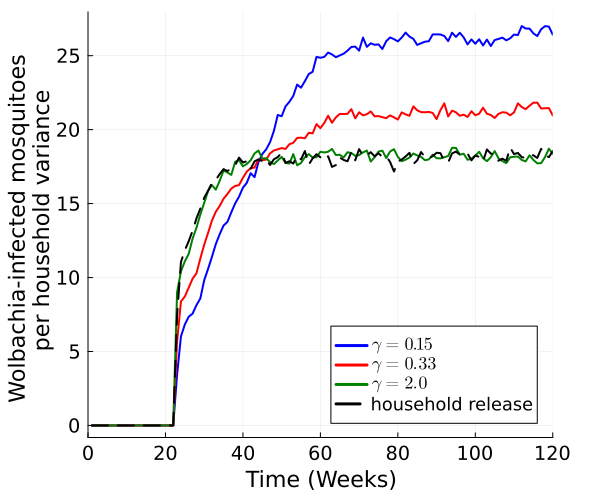

In [56]:
using Measures

p=plot(row_var_w_tot_015, xlabel="Time (Weeks)", ylabel="Wolbachia-infected mosquitoes \n per household variance",titlefont=font(14), label ="\$\\gamma=0.15\$",linecolor=:blue,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)

plot!(row_var_w_tot_033, label ="\$\\gamma=0.33\$", linecolor=:red,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)

plot!(row_var_w_tot_2, label ="\$\\gamma=2.0\$", linecolor=:green,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)

plot!(row_var_w_tot_h, label ="household release", linecolor=:black, linestyle=:dash,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)

plot!(xlim=(0,120),size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2,
legendfont=font(12),
legend=:bottomright,
right_margin=10mm
)
savefig(p, "variance_01_gammas_033_033_100__150_8_relhhold.pdf")
#plot!(legend=(0.6,0.8))
p

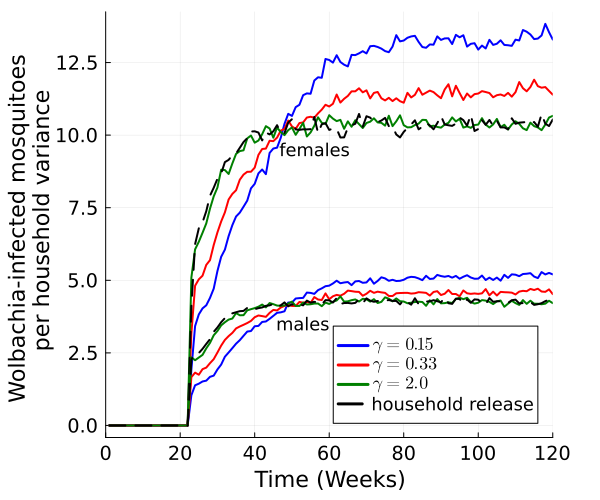

In [66]:
p=plot(row_var_fem_w_015, xlabel="Time (Weeks)", ylabel="Wolbachia-infected mosquitoes \n per household variance",titlefont=font(14), label ="\$\\gamma=0.15\$", linecolor=:blue,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)
plot!(row_var_fem_w_033, label ="\$\\gamma=0.33\$", linecolor=:red,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)
plot!(row_var_fem_w_2, label ="\$\\gamma=2.0\$", linecolor=:green,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)
plot!(row_var_fem_w_h, label ="household release", linecolor=:black, linestyle=:dash,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)

plot!(row_var_male_w_015, label=false, linecolor=:blue,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)
plot!(row_var_male_w_033, label=false, linecolor=:red,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)
plot!(row_var_male_w_2, label=false, linecolor=:green,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)
plot!(row_var_male_w_h, linecolor=:black, linestyle=:dash, label=false,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)
plot!(xlim=(0,120),size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2,
legendfont=font(12),
legend=:bottomright,
right_margin=10mm
)
annotate!(53, 3.5, text("males", :black, 12))
annotate!(56, 9.5, text("females", :black, 12))
savefig(p, "variance_01_gammasfem_033_033_100__150_8_relhhold.pdf")
#plot!(legend=(0.6,0.8))
p